## Basic routine

In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

In [1]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters
from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit_algorithms.optimizers import COBYLA, SLSQP
from qiskit_algorithms.minimum_eigensolvers import SamplingVQE
from qiskit.primitives import Sampler
import matplotlib.pyplot as plt
import numpy as np
from qiskit.quantum_info import Statevector
from sklearn.metrics import r2_score
import pickle

In [15]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    # print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun, penalty_olap)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(
        peptide, mj_interaction, penalty_terms
    )

    return protein_folding_problem

In [3]:
main_seq_4 = "LFLF" # 6MVZ ("LFLF")
# main_seq_5 = "LGKAT" # made up
# main_seq_6 = "DEGKAT" # made up
# main_seq_7 = "LHPGAGK" # Zika
# protein_folding_problem = build_pf(main_seq)

In [20]:
num_qubits = []
num_ham_terms = []
for main_seq in [main_seq_4, main_seq_5, main_seq_6, main_seq_7]:
    protein_folding_problem = build_pf(main_seq)
    qubit_op = protein_folding_problem.qubit_op()
    num_qubits.append(qubit_op.num_qubits)
    num_ham_terms.append(len(qubit_op))
    print(f"Number of qubits: {qubit_op.num_qubits}")
    print(f"Number of terms: {len(qubit_op)}")

Number of qubits: 9
Number of terms: 131
Number of qubits: 16
Number of terms: 1533
Number of qubits: 24
Number of terms: 18133
Number of qubits: 33
Number of terms: 266454


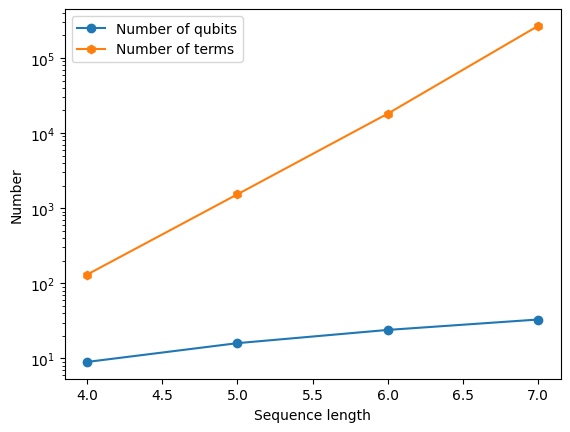

In [22]:
# Plot the number of qubits and number of terms (log scale)
plt.figure()
plt.plot([4, 5, 6, 7], num_qubits, label="Number of qubits", marker="o")
plt.plot([4, 5, 6, 7], num_ham_terms, label="Number of terms", marker="h")
plt.yscale("log")
plt.xlabel("Sequence length")
plt.ylabel("Number")
plt.legend()

In [16]:
# main_seq = "LHPGAGK" # Zika
main_seq = "LFLF" # 6MVZ ("LFLF")
protein_folding_problem = build_pf(main_seq)

qubit_op = protein_folding_problem.qubit_op()
print("Number of qubits: ", qubit_op.num_qubits)
print("Number of terms: ", len(qubit_op))
print(qubit_op)

Highest degree of the polynomial for 0 and 3: 7
Number of qubits:  9
Number of terms:  131
SparsePauliOp(['IIIIIIIII', 'IIIZZIIII', 'IIIZIZZII', 'IIIIZZZII', 'IIIIIIZZI', 'IIIZZIZZI', 'IIIZIZIZI', 'IIIIZZIZI', 'IIIIIZIIZ', 'IIIZZZIIZ', 'IIIZIIZIZ', 'IIIIZIZIZ', 'IIIIIZZZZ', 'IIIZZZZZZ', 'IIIZIIIZZ', 'IIIIZIIZZ', 'IIIIIZZII', 'IIIZZZZII', 'IIIIIIIZI', 'IIIIIZIII', 'IIIZIZIII', 'IIIIZZIII', 'IIIZZZIII', 'IIIIIIZII', 'IIIZIIZII', 'IIIIZIZII', 'IIIZZIZII', 'IIIIIZIZI', 'IIIZZZIZI', 'IIIZIIZZI', 'IIIZIIIII', 'IIIIZIIII', 'IIIIIIIZZ', 'IIIIIZIZZ', 'IIIZZZIZZ', 'IIIIIIZZZ', 'IIIZZIZZZ', 'IIIZIZZZZ', 'IIIIZZZZZ', 'IIIIZZIIZ', 'IIIIZIZZI', 'IIIZIIIZI', 'IIIIZIIZI', 'IIIZZIIZI', 'IIIIIZZZI', 'IIIZIZZZI', 'IIIIZZZZI', 'IIIZZZZZI', 'IIIIIIIIZ', 'IIIZIIIIZ', 'IIIIZIIIZ', 'IIIIIIZIZ', 'IIIZZIZIZ', 'IIIZIZZIZ', 'IIIIZZZIZ', 'IIIIZZIZZ', 'IIIIZIZZZ', 'IIIZIZIZZ', 'IIIZZIIZZ', 'IIIZIIZZZ', 'IIIZIZIIZ', 'IIIZZIIIZ', 'IIIZZZZIZ', 'IIIIIZZIZ', 'IIZIIIIII', 'IIZIIIIZI', 'IIZIIIIZZ', 'IZIIIIIII', 'IZIIIIIZI

In [17]:
def run_sampling_vqe(qubit_op):
    # set classical optimizer
    optimizer = SLSQP(maxiter=100)

    # set variational ansatz
    ansatz = RealAmplitudes(reps=2)

    counts = []
    values = []

    def store_intermediate_result(eval_count, parameters, mean, std):
        counts.append(eval_count)
        values.append(mean)

    # initialize VQE using CVaR with alpha = 0.1
    vqe = SamplingVQE(
        Sampler(),
        ansatz=ansatz,
        optimizer=optimizer,
        aggregation=0.1,
        callback=store_intermediate_result,
    )

    raw_result = vqe.compute_minimum_eigenvalue(qubit_op)

    return raw_result, counts, values

In [18]:
raw_result, counts, values = run_sampling_vqe(qubit_op)

/Users/ruihaoli/opt/miniconda3/envs/qc_pf/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ruihaoli/opt/miniconda3/envs/qc_pf/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


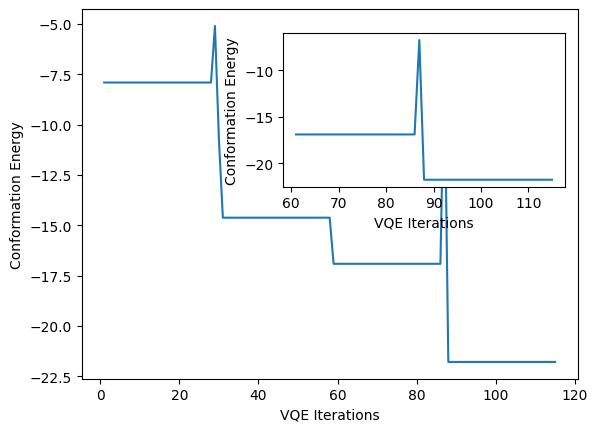

In [19]:
fig = plt.figure()

plt.plot(counts, values)
plt.ylabel("Conformation Energy")
plt.xlabel("VQE Iterations")

fig.add_axes([0.44, 0.51, 0.44, 0.32])

plt.plot(counts[60:], values[60:])
plt.ylabel("Conformation Energy")
plt.xlabel("VQE Iterations")
plt.show()

In [20]:
# Save raw_result into a file
with open(f"raw_result_{main_seq}.pkl", "wb") as f:
    pickle.dump(raw_result, f)

In [21]:
with open(f"raw_result_{main_seq}.pkl", "rb") as f:
    raw_result = pickle.load(f)

raw_result.best_measurement

{'state': 510,
 'bitstring': '111111110',
 'value': (-21.778366927190394+0j),
 'probability': 0.2597062288700764}

In [22]:
from fcc.fcc_protein_shape import ProteinShapeDecoder
sol_bitstring = raw_result.best_measurement["bitstring"]
peptide = Peptide(main_seq)
protein_shape_decoder = ProteinShapeDecoder(peptide, sol_bitstring)
protein_shape_decoder.turn_sequence

[0, 9, 3]

Best turn bitstring:  111111110
Best turn sequence:  [0, 9, 3]
Best turn energy:  -21.778366927190397


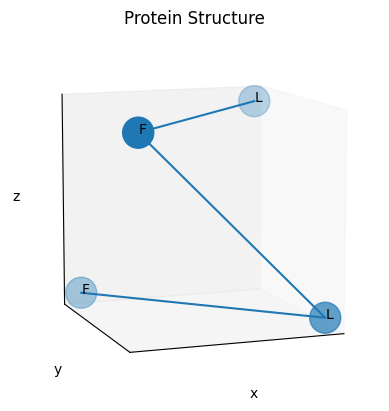

In [23]:
result = protein_folding_problem.interpret(raw_result)
print("Best turn bitstring: ", result.solution_bitstring)
print("Best turn sequence: ", result.turn_sequence)
print("Best turn energy: ", raw_result.eigenvalue)
fig = result.get_figure(ticks=False, grid=True)
fig.get_axes()[0].view_init(elev=10, azim=70)

In [13]:
xyz_coords = result.protein_shape_file_gen.get_xyz_data()
print(xyz_coords)
xyz_coords = xyz_coords[:, 1::]
# Convert the coordinates to float
xyz_coords = xyz_coords.astype(float)
# Compute distances between all pairs of atoms
distances = []
for i in range(len(xyz_coords)):
    for j in range(i + 2, len(xyz_coords)):
        distance = (np.linalg.norm(xyz_coords[i] - xyz_coords[j]) / 3.8 * np.sqrt(2)) ** 2
        distances.append(distance)
print(distances)

[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '2.68700576850888' '0.0' '-2.68700576850888']
 ['K' '2.68700576850888' '-2.68700576850888' '0.0']]
[1.9999999999999996, 1.9999999999999996, 1.9999999999999996, 1.9999999999999996, 4.0, 5.999999999999999]


## Profiling and Checks

In [26]:
from fcc.fcc_mj_interaction import _load_energy_matrix_file

mj_matrix, _ = _load_energy_matrix_file()
# print(f"max energy (not equal to zero): {mj_matrix[mj_matrix != 0].max()}")
# print(f"min energy: {mj_matrix.min()}")
mj_matrix.shape

(20, 20)

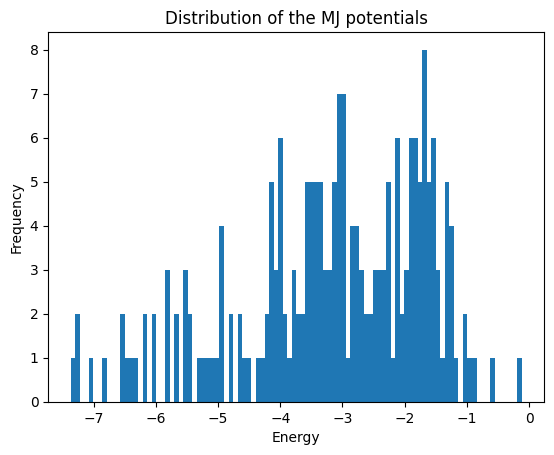

In [28]:
# Plot the distribution of the MJ potentials
plt.figure()
plt.hist(mj_matrix[mj_matrix != 0.0].flatten(), bins=100)
plt.xlabel("Energy")
plt.ylabel("Frequency")
plt.title("Distribution of the MJ potentials")
plt.show()

In [ ]:
from fcc.fcc_qubit_op_builder import QubitOpBuilder
peptide = Peptide(main_seq)
mj_interaction = MiyazawaJerniganInteraction()
pairwise_energies = mj_interaction.calculate_energy_matrix(peptide.peptide_sequence)
penalty_parameters = PenaltyParameters(penalty_back = 50, penalty_redun = 50, penalty_olap = 50)
qubit_op_builder = QubitOpBuilder(peptide, pairwise_energies, penalty_parameters)
%lprun -u 1e-1 -f QubitOpBuilder._create_h_olap qubit_op_builder._create_h_olap() 

Highest degree of the polynomial for 0 and 3: 6
Penalty values: [49.84265734  0.85664336 -1.71328671  1.22377622  0.48951049 -0.97902098
 -0.24475524  1.01398601 -0.61188811  0.12237762]
Highest degree of the polynomial for 0 and 4: 8
Penalty values: [49.72001615  1.41741823 -2.36236371  0.78745457  1.272042   -0.10903217
 -0.98128954 -0.54516086  0.424014    0.80091533  0.23017903 -0.5936196
 -0.62592543  0.30286714  0.78745457 -0.68246063  0.15749091]
Highest degree of the polynomial for 1 and 4: 6
Penalty values: [49.84265734  0.85664336 -1.71328671  1.22377622  0.48951049 -0.97902098
 -0.24475524  1.01398601 -0.61188811  0.12237762]


Timer unit: 0.1 s

Total time: 0.656895 s
File: /Users/lir9/protein-folding-qc/notebooks/../fcc/fcc_qubit_op_builder.py
Function: _create_h_olap at line 156

Line #      Hits         Time  Per Hit   % Time  Line Contents
   156                                               def _create_h_olap(self) -> SparsePauliOp:
   157                                                   r"""
   158                                                   Creates qubit operators for the H_olap term, which penalizes overlapping beads. To ensure the non-overlapping condition, we impose constraints on the distance function that encodes the squared distance between beads, that is, for any two beads :math:`i` and :math:`j`, we require :math:`2 \leq D_{ij} leq 2(i-j)^2`.
   159                                                   For each pair of beads, we define :math:`h_{ij} = D_{ij} - 2`. Ideally, the penalty function would have a large positive value (set by `penalty_olap`) when :math:`h_{ij} = -2` (corresponding 

In [23]:
main_seq = "DALLAD"
peptide = Peptide(main_seq)
mj_interaction = MiyazawaJerniganInteraction()
pairwise_energies = mj_interaction.calculate_energy_matrix(peptide.peptide_sequence)
print(pairwise_energies)

[[ 0.   -1.7  -3.4  -3.4  -1.7  -1.21]
 [ 0.    0.   -4.91 -4.91 -2.72 -1.7 ]
 [ 0.    0.    0.   -7.37 -4.91 -3.4 ]
 [ 0.    0.    0.    0.   -4.91 -3.4 ]
 [ 0.    0.    0.    0.    0.   -1.7 ]
 [ 0.    0.    0.    0.    0.    0.  ]]


In [ ]:
# Check h_olap
from fcc.utils import remove_unused_qubits, build_full_identity
h_olap = remove_unused_qubits(qubit_op_builder._create_h_olap())
print(h_olap)

Highest degree of the polynomial for 0 and 3: 6
[49.84265734  0.85664336 -1.71328671  1.22377622  0.48951049 -0.97902098
 -0.24475524  1.01398601 -0.61188811  0.12237762]
(SparsePauliOp(['IIIIII', 'IIIIZI', 'IIZIII', 'ZIZIII', 'IZZIII', 'ZZZIII', 'IIIZII', 'ZIIZII', 'IZIZII', 'ZZIZII', 'IIZIZI', 'ZIZIZI', 'IZZIZI', 'ZZZIZI', 'IIIZZI', 'ZIIZZI', 'ZZIZZI', 'ZIIIII', 'IZIIII', 'ZZIIII', 'IIZZII', 'ZIZZII', 'IZZZII', 'ZZZZII', 'IIIIZZ', 'ZIIIZZ', 'IZIIZZ', 'IIZIZZ', 'ZZZIZZ', 'IIIZZZ', 'ZZIZZZ', 'ZIZZZZ', 'IZZZZZ', 'IZZIIZ', 'IZIZIZ', 'IZIZZI', 'ZIIIZI', 'IZIIZI', 'ZZIIZI', 'IIZZZI', 'ZIZZZI', 'IZZZZI', 'ZZZZZI', 'IIIIIZ', 'ZIIIIZ', 'IZIIIZ', 'IIZIIZ', 'ZZZIIZ', 'IIIZIZ', 'ZZIZIZ', 'ZIZZIZ', 'IZZZIZ', 'IZZIZZ', 'IZIZZZ', 'ZIZIZZ', 'ZZIIZZ', 'ZZZZZZ', 'ZIIZZZ', 'ZIZIIZ', 'ZIIZIZ', 'ZZIIIZ', 'ZZZZIZ', 'IIZZZZ', 'IIZZIZ'],
              coeffs=[ 1.16067526+0.j, -0.59577142+0.j, -0.77933785+0.j, -0.81211757+0.j,
  0.77605988+0.j,  0.84489729+0.j,  0.92192963+0.j,  0.72525131+0.j,
 -0.86292614+

In [ ]:
h_olap_full = build_full_identity(3) ^ h_olap[0]
opt_state = Statevector.from_label("101100110")
print(opt_state.data.conj().T @ h_olap_full.to_matrix() @ opt_state.data)

(-1.713286713286525+0j)


In [ ]:
# Check h_contact
h_contact = remove_unused_qubits(qubit_op_builder._create_h_contact())
print(opt_state.data.conj().T @ h_contact[0].to_matrix() @ opt_state.data)

(-14.630000000000004+0j)


## VQE routine

In [ ]:
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import NELDER_MEAD
from qiskit_aer import Estimator, Sampler

In [99]:
main_seq = "LFLF" # 6MVZ ("LFLF")
protein_folding_problem = build_pf(main_seq)
qubit_op = protein_folding_problem.qubit_op()
print("Number of qubits: ", qubit_op.num_qubits)
print("Number of terms: ", len(qubit_op))

Number of qubits:  9
Number of terms:  131


In [106]:
def run_vqe(qubit_op):
    # set classical optimizer
    optimizer = SLSQP(maxiter=600)

    # set variational ansatz
    ansatz = RealAmplitudes(reps=1)

    counts = []
    values = []

    def store_intermediate_result(eval_count, parameters, mean, std):
        counts.append(eval_count)
        values.append(mean)

    vqe = VQE(
        Estimator(),
        ansatz=ansatz,
        optimizer=optimizer,
        callback=store_intermediate_result,
    )

    vqe_result = vqe.compute_minimum_eigenvalue(qubit_op)
    circ = vqe_result.optimal_circuit.assign_parameters(vqe_result.optimal_parameters)
    circ = circ.measure_all(inplace=False)
    circ.draw("mpl")
    # Run the optimal circuit with sampler
    raw_result = Sampler().run(circ).result()

    return raw_result, counts, values

In [107]:
raw_result, counts, values = run_vqe(qubit_op)

/Users/lir9/miniconda3/envs/pf_qiskit_1/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/Users/lir9/miniconda3/envs/pf_qiskit_1/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:441: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)


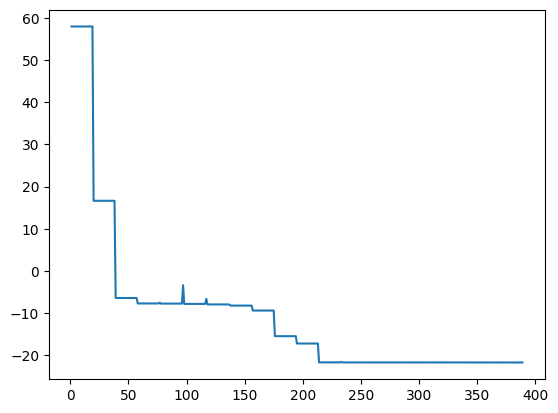

In [108]:
plt.plot(counts, values)

In [109]:
def compute_energy(qubit_op, bitstring):
    state = Statevector.from_label(bitstring).data
    energy = state.conj().T @ qubit_op.to_matrix() @ state
    return energy.real

Best turn bitstring:  111111110
Best turn sequence:  [0, 9, 3]
Best turn energy:  -21.778366927190397


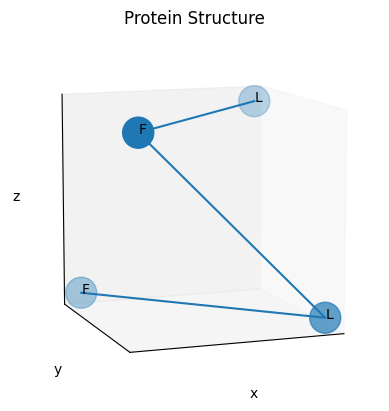

In [110]:
result = protein_folding_problem.interpret(raw_result)
print("Best turn bitstring: ", result.solution_bitstring)
print("Best turn sequence: ", result.turn_sequence)
print("Best turn energy: ", compute_energy(qubit_op, result.solution_bitstring))
fig = result.get_figure(ticks=False, grid=True)
fig.get_axes()[0].view_init(elev=10, azim=70)

In [105]:
xyz_coords = result.protein_shape_file_gen.get_xyz_data()
print(xyz_coords)
xyz_coords = xyz_coords[:, 1::]
# Convert the coordinates to float
xyz_coords = xyz_coords.astype(float)
# Compute distances between all pairs of atoms
distances = []
for i in range(len(xyz_coords)):
    for j in range(i + 2, len(xyz_coords)):
        distance = (np.linalg.norm(xyz_coords[i] - xyz_coords[j]) / 3.8 * np.sqrt(2)) ** 2
        distances.append(distance)
print(distances)

[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '2.68700576850888' '0.0' '-2.68700576850888']]
[1.9999999999999996, 1.9999999999999996, 1.9999999999999996]


In [111]:
main_seq = "DALLAD" # 2K2R partial
protein_folding_problem = build_pf(main_seq)
qubit_op = protein_folding_problem.qubit_op()
print("Number of qubits: ", qubit_op.num_qubits)
print("Number of terms: ", len(qubit_op))

Highest degree of the polynomial for 0 and 3: 7
Penalty values: [ 4.99814891e+01  1.31633073e-01 -3.86672151e-01  5.75894694e-01
 -3.74331551e-01 -1.15178939e-01  4.03126285e-01 -3.12628548e-01
  1.13122172e-01 -1.64541341e-02]
Highest degree of the polynomial for 0 and 4: 10
Penalty values: [ 4.99832488e+01  1.26680726e-01 -3.80042177e-01  5.24820149e-01
 -1.99069712e-01 -2.71458698e-01  1.69456036e-01  2.25392979e-01
 -1.03647866e-01 -2.18812163e-01  5.10013311e-02  2.15820882e-01
 -5.10013313e-02 -2.15521754e-01  2.12231345e-01 -8.06150087e-02
  1.15164275e-02]
